In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd, orth, qr
from scipy.optimize import curve_fit
from numpy import sin, cos, pi
cmap = plt.cm.plasma
from scipy.ndimage import gaussian_filter1d
from scipy.signal import wiener
from scipy.signal import wiener, butter, freqs, convolve, freqz
from scipy.fft import fft, ifft, fftshift, ifftshift, fftfreq
from scipy.interpolate import (RegularGridInterpolator, RectBivariateSpline,
                               interpn, griddata, Rbf, interp1d, interp2d)
import cv2
from scipy.signal import convolve2d as conv2
from skimage import color, data, restoration
from smooth_POD_ROM.reduced_order_model import pulse, delta_n_width, train_ROM, L2_error, zielfunktion
from smooth_POD_ROM.pre_processing import convolve_f, gaussian_f, gaussian, smoothen
from smooth_POD_ROM.post_processing import richardson_lucy, post_process
from scipy.optimize import minimize
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 2.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=False)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 40

8.030570172000001


In [ ]:
# generate training data
# make rom of rank r
# predict test data
# has gibbs?
# repeat with smooth data

In [18]:
m, n = 10000, 1000
n_test = 5
x = np.linspace(0, 1, m, endpoint=False)
mu_train = np.linspace(0.0, 1, n, endpoint=False)[:, None]  # +1/(2*n)
mu_test = np.random.rand(n_test)[:, None]
print(mu_test)


sigma = 0.05
num_iter1 = 10
num_iter2 = 250
mode = "constant"
rank = 10  # n
dx = 1/m
c = 2
shape = (m,)
clip = True

[[0.70578121]
 [0.96593874]
 [0.40184971]
 [0.3564334 ]
 [0.79209191]]


In [19]:
X_train = np.empty((m, len(mu_train)))
X_test = np.zeros((m, len(mu_test)))

for _mu, _X in zip([mu_train, mu_test], [X_train, X_test]):
    for j, mu_j in enumerate(_mu):
        y = pulse(x, mu_j)
        _X[:, j] = y
X_train_s = smoothen(X_train, sigma/dx, x.shape, truncate=4)
X_test_s = smoothen(X_test, sigma/dx, x.shape, truncate=4)

In [20]:
standard_rom = train_ROM(mu_train, X_train, rank=rank)
X_test_ROM = standard_rom.predict(mu_test).T

X_train_s = smoothen(X_train, sigma/dx, shape)
smooth_rom = train_ROM(mu_train, X_train_s, rank=rank)
X_test_sROM = smooth_rom.predict(mu_test).T

X_test_sROMs = post_process(x, X_test_sROM, sigma, c, mu_test, mu_train, num_iter1,
                            shape, clip=clip, progress=False)
X_test_sROMs2 = post_process(x, X_test_sROM, sigma, c, mu_test, mu_train, num_iter2,
                            shape, clip=clip, progress=False)

# pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/Pulse/"
# pth = "/home/florianma@ad.ife.no/matpro_files/Florian/results/sPODROM/"
# np.save(pth+"X_test.npy", X_test)
# np.save(pth+"X_test_s.npy", X_test_s)
# np.save(pth+"X_test_ROM.npy", X_test_ROM)
# np.save(pth+"X_test_sROM.npy", X_test_sROM)

/home/florianma@ad.ife.no/matpro_files/Florian/Repositoties/POD-ROM-and-gaussian-convolution/src/smooth_POD_ROM/post_processing.py:24: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


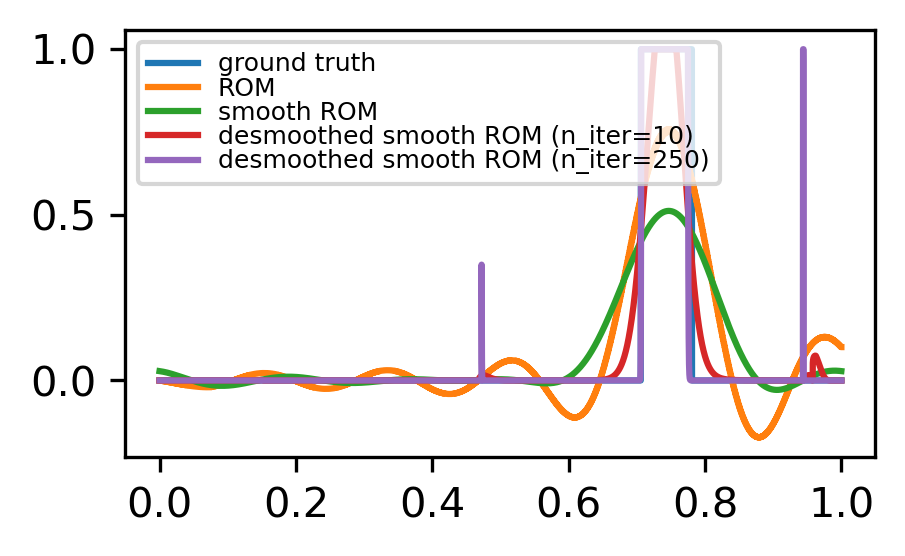

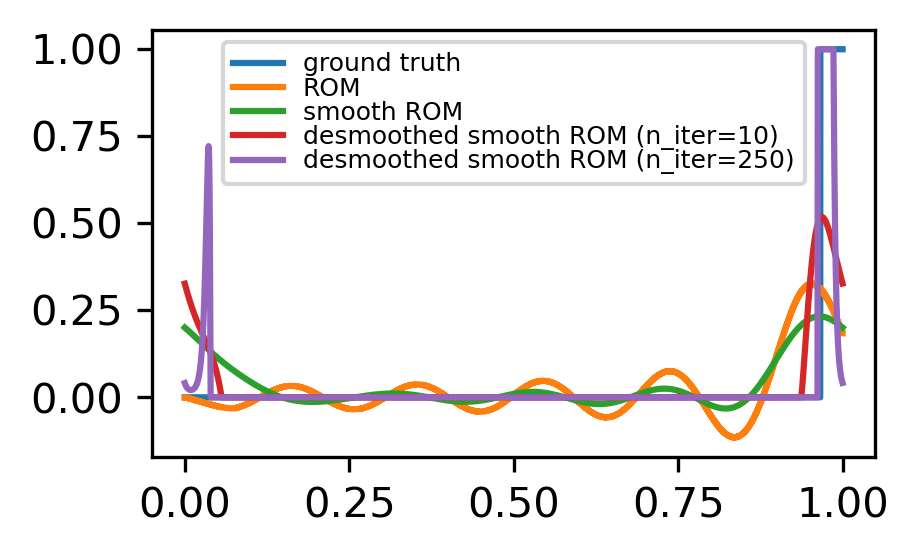

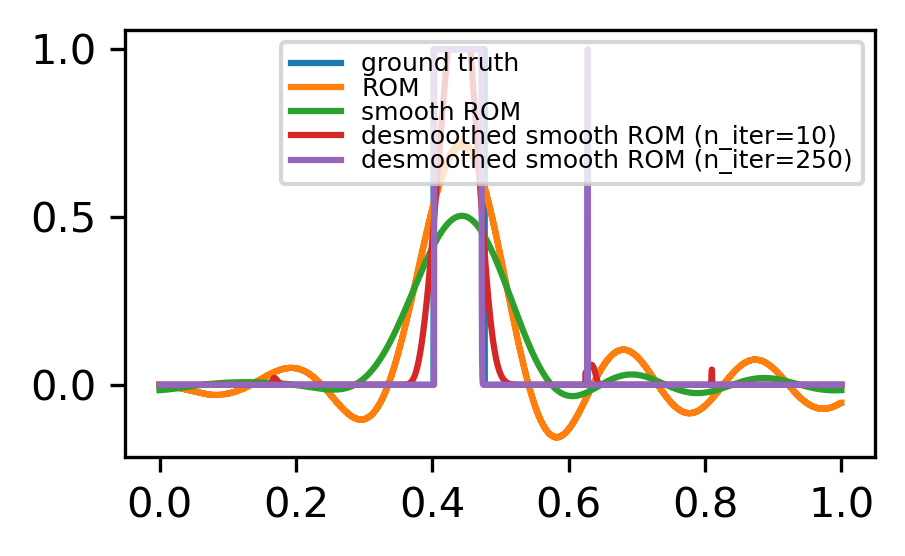

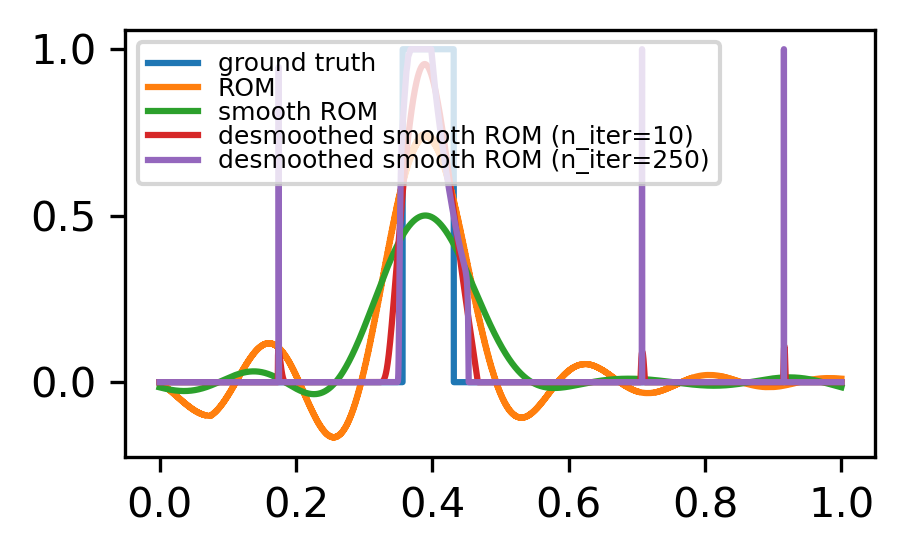

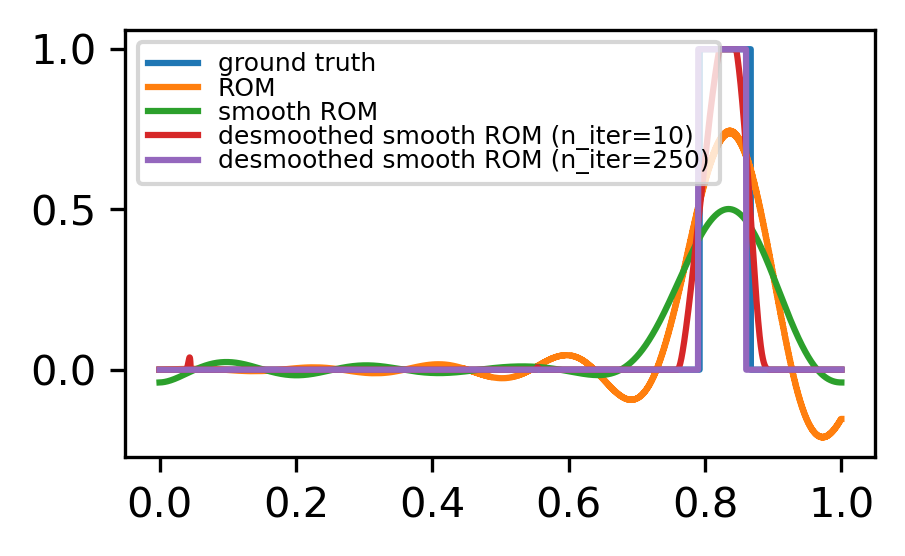

In [23]:
for j in range(n_test):
    fig, ax = plt.subplots()
    plt.plot(x, X_test[:, j], label="ground truth")
    plt.plot(x, X_test_ROM[:, j], label="ROM")
    plt.plot(x, X_test_sROM[:, j], label="smooth ROM")
    plt.plot(x, X_test_sROMs[:, j], label="desmoothed smooth ROM (n_iter=10)")
    plt.plot(x, X_test_sROMs2[:, j], label="desmoothed smooth ROM (n_iter=250)")
    plt.legend()
    plt.show()